<a href="https://colab.research.google.com/github/LIBY70/Deep_learning/blob/main/DL26_1_hw1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Trying: https://github.com/JKim-DIA/AI.Campus/blob/main/AIcampus25_dataset1.zip?raw=1
Downloaded to: data/AIcampus25_dataset1.zip
Extracting to: data/AIcampus25_dataset1
Found train dir: data/AIcampus25_dataset1/CNN_train
Found test  dir: data/AIcampus25_dataset1/CNN_test
Detected classes (5): ['bed', 'chair', 'sofa', 'swivelchair', 'table']
Epoch 1/10, Loss: 4.5976
Epoch 2/10, Loss: 1.7370
Epoch 3/10, Loss: 1.0624
Epoch 4/10, Loss: 0.8512
Epoch 5/10, Loss: 0.7325
Epoch 6/10, Loss: 0.6093
Epoch 7/10, Loss: 0.5314
Epoch 8/10, Loss: 0.4665
Epoch 9/10, Loss: 0.3797
Epoch 10/10, Loss: 0.3490
Accuracy: 73.00%


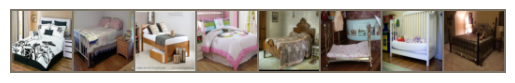

GroundTruth:  bed bed bed bed bed bed bed bed
Predicted:    chair bed bed bed bed bed bed table


In [ ]:
import os
import io
import zipfile
import urllib.request
from glob import glob
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, random_split, Subset
import torch.nn.functional as F

# =========================================================
# 0. 기본 설정
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 64
learning_rate = 1e-3
num_epochs = 10
root_dir = Path("./data")
root_dir.mkdir(parents=True, exist_ok=True)

# 깃허브 ZIP (blob 링크 -> raw 링크/쿼리 모두 시도)
GITHUB_BLOB_URL = "https://github.com/JKim-DIA/AI.Campus/blob/main/AIcampus25_dataset1.zip"
CANDIDATE_URLS = [
    GITHUB_BLOB_URL + "?raw=1",
    "https://raw.githubusercontent.com/JKim-DIA/AI.Campus/main/AIcampus25_dataset1.zip",
]
zip_path = root_dir / "AIcampus25_dataset1.zip"
extract_dir = root_dir / "AIcampus25_dataset1"

# =========================================================
# 1. ZIP 다운로드 & 압축 해제
# =========================================================
def download_zip(urls, dst_path):
    for u in urls:
        try:
            print(f"Trying: {u}")
            urllib.request.urlretrieve(u, dst_path)
            print(f"Downloaded to: {dst_path}")
            return True
        except Exception as e:
            print(f"  Failed: {e}")
    return False

def safe_extract(zip_file: zipfile.ZipFile, path: Path):
    # 간단한 Zip Slip 방지
    for member in zip_file.namelist():
        member_path = (path / member).resolve()
        if not str(member_path).startswith(str(path.resolve())):
            raise Exception("Unsafe zip path detected!")
    zip_file.extractall(path)

if not extract_dir.exists():
    ok = download_zip(CANDIDATE_URLS, zip_path)
    if not ok:
        raise RuntimeError("데이터셋 ZIP 다운로드에 실패했습니다. URL을 확인하세요.")
    with zipfile.ZipFile(zip_path, "r") as zf:
        print(f"Extracting to: {extract_dir}")
        safe_extract(zf, extract_dir)
else:
    print(f"Already extracted at: {extract_dir}")

# =========================================================
# 2. 데이터 전처리 & 경로 자동 탐지
# =========================================================
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# 후보 폴더명 패턴
TRAIN_CANDIDATES = ["train", "training", "cnn_train", "train_images"]
TEST_CANDIDATES  = ["test", "testing", "cnn_test", "val", "validation"]

def find_dir_by_names(base: Path, name_keywords):
    # 이름에 키워드를 포함하는 디렉토리를 깊이 3까지 탐색
    for depth in range(3):
        pattern = str(base / ("*/" * depth))
        for p in glob(pattern or str(base)):
            pth = Path(p)
            if pth.is_dir() and any(k in pth.name.lower() for k in name_keywords):
                return pth
    return None

def dir_looks_like_classroot(d: Path):
    """하위에 여러 클래스 디렉토리(폴더)와 이미지가 있는지 간단히 검사"""
    if not d or not d.exists(): return False
    subdirs = [x for x in d.iterdir() if x.is_dir()]
    if len(subdirs) < 2:
        return False
    # 각 서브디렉토리에 이미지가 있는지 대략 확인
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp"}
    sub_with_images = 0
    for sd in subdirs:
        imgs = [f for f in sd.glob("*") if f.suffix.lower() in exts]
        if len(imgs) > 0:
            sub_with_images += 1
    return sub_with_images >= max(1, len(subdirs) // 2)

# 1) 우선 이름 기반으로 train/test 폴더 찾기
train_dir = find_dir_by_names(extract_dir, TRAIN_CANDIDATES)
test_dir  = find_dir_by_names(extract_dir, TEST_CANDIDATES)

# 2) 못 찾으면, 클래스 루트로 보이는 디렉토리 하나를 찾아 8:2로 분할
split_needed = False
if train_dir and test_dir:
    print(f"Found train dir: {train_dir}")
    print(f"Found test  dir: {test_dir}")
    train_data = datasets.ImageFolder(root=str(train_dir), transform=transform)
    test_data  = datasets.ImageFolder(root=str(test_dir),  transform=transform)
else:
    print("Named train/test 폴더를 찾지 못했습니다. 클래스 루트 탐색 후 8:2로 자동 분할합니다.")
    candidate_roots = []
    for child in extract_dir.rglob("*"):
        if child.is_dir() and dir_looks_like_classroot(child):
            candidate_roots.append(child)
    if not candidate_roots:
        # 최후의 수단: 최상위 폴더가 바로 class root일 수도 있음
        if dir_looks_like_classroot(extract_dir):
            candidate_roots = [extract_dir]
    if not candidate_roots:
        raise RuntimeError("클래스 폴더 구조를 찾지 못했습니다. ZIP 내부 구조를 확인하세요.")

    class_root = candidate_roots[0]
    print(f"Class root assumed at: {class_root}")
    full_dataset = datasets.ImageFolder(root=str(class_root), transform=transform)

    # 8:2 split (고정 시드)
    train_len = int(0.8 * len(full_dataset))
    test_len = len(full_dataset) - train_len
    train_data, test_data = random_split(
        full_dataset, [train_len, test_len],
        generator=torch.Generator().manual_seed(42)
    )
    split_needed = True

# 클래스 이름 얻기
if split_needed:
    classes = full_dataset.classes
else:
    classes = train_data.classes

num_classes = len(classes)
print(f"Detected classes ({num_classes}): {classes}")

# =========================================================
# 3. DataLoader
# =========================================================
# Subset인 경우 pin_memory를 위해 collate에 문제 없음
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True,
                          num_workers=2, pin_memory=torch.cuda.is_available())
test_loader  = DataLoader(test_data,  batch_size=batch_size, shuffle=False,
                          num_workers=2, pin_memory=torch.cuda.is_available())

# =========================================================
# 4. 모델 정의
# =========================================================
class FurnitureCNN(nn.Module):
    def __init__(self, num_classes):
        super(FurnitureCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)
        self.pool  = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.1)

        self.fc1 = nn.Linear(128 * 8 * 8, 512)  # 64 -> 32 -> 16 -> 8
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = FurnitureCNN(num_classes=num_classes).to(device)

# =========================================================
# 5. 손실/옵티마이저
# =========================================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# =========================================================
# 6. 학습/평가 루프
# =========================================================
def train_model(model, train_loader, criterion, optimizer, num_epochs):
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f'Epoch {epoch + 1}/{num_epochs}, Loss: {running_loss / max(1, len(train_loader)):.4f}')

def evaluate_model(model, test_loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    acc = 100.0 * correct / max(1, total)
    print(f'Accuracy: {acc:.2f}%')

train_model(model, train_loader, criterion, optimizer, num_epochs)
evaluate_model(model, test_loader)

# =========================================================
# 7. 시각화
# =========================================================
import torchvision
import matplotlib.pyplot as plt
import numpy as np

def imshow(img):
    img = img.cpu().clone()
    img = img * torch.tensor([0.229, 0.224, 0.225]).view(3,1,1) + torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis("off")
    plt.show()

def visualize_predictions(model, test_loader, classes):
    dataiter = iter(test_loader)
    images, labels = next(dataiter)
    images, labels = images.to(device), labels.to(device)

    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

    imshow(torchvision.utils.make_grid(images[:8]))
    k = min(8, images.size(0))
    gt = ' '.join(f'{classes[labels[j].item()]}' for j in range(k))
    pr = ' '.join(f'{classes[predicted[j].item()]}' for j in range(k))
    print('GroundTruth: ', gt)
    print('Predicted:   ', pr)

# classes 추출 (Subset일 수도 있음)
if isinstance(train_data, Subset):
    classes_for_vis = train_data.dataset.classes
else:
    classes_for_vis = train_data.classes

visualize_predictions(model, test_loader, classes_for_vis)
